# import libraries

In [28]:
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestRegressor,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.inspection import permutation_importance


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [29]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [30]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "../../data/postings.csv"
COMPANIES_PATH = "../../data/companies.csv"
EMP_COUNTS_PATH = "../../data/employee_counts.csv"
JOB_SKILLS_PATH = "../../data/job_skills.csv"
SKILL_MAP_PATH = "../../data/skill_mapping.csv"

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [31]:
# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

In [32]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


In [33]:
# làm sạch biến địa lí
for col in ["country", "state", "city"]:
    if col in job_merged.columns:
        job_merged[col] = job_merged[col].replace("0", np.nan)
        job_merged[col] = job_merged[col].fillna("Unknown")

# chuẩn hóa dữ liệu kiểu số
numeric_cols = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary",
    "views",
    "applies",
    "employee_count",
    "follower_count",
]

for col in numeric_cols:
    if col in job_merged.columns:
        job_merged[col] = pd.to_numeric(job_merged[col], errors="coerce")

# xử lí mô tả công việc và tạo cột mới
job_merged["description"] = job_merged["description"].fillna("")
job_merged["description_norm"] = (
    job_merged["description"].fillna("").apply(normalize_text)
)

# 1. Chuẩn hóa giá trị formatted_experience_level
job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .astype(str)
    .str.strip()
)

# Quy về nhóm thống nhất
exp_map = {
    "Internship": "Intern",
    "Entry level": "Entry",
    "Associate": "Entry",
    "Mid-Senior level": "Mid",
    "Director": "Senior",
    "Executive": "Executive",
    "nan": np.nan
}

job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .replace(exp_map)
)

# 2. Hàm trích experience level từ title (chỉ dùng để fill NaN)
def extract_exp_from_title(title: str):
    if pd.isna(title):
        return np.nan
    t = title.lower()
    if re.search(r"\b(intern|internship|trainee)\b", t):
        return "Intern"
    if re.search(r"\b(junior|jr\.?)\b", t):
        return "Entry"
    if re.search(r"\b(senior|sr\.?)\b", t):
        return "Senior"
    if re.search(r"\b(lead|principal|staff)\b", t):
        return "Senior"
    if re.search(r"\b(manager|head)\b", t):
        return "Mid"
    if re.search(r"\b(director|vp|vice president)\b", t):
        return "Senior"
    if re.search(r"\b(c-level|cto|cfo|ceo|chief)\b", t):
        return "Executive"
    return np.nan

# 3. Fill missing formatted_experience_level bằng title
mask_missing = job_merged["formatted_experience_level"].isna()
job_merged.loc[mask_missing, "formatted_experience_level"] = (
    job_merged.loc[mask_missing, "title"]
    .apply(extract_exp_from_title)
)

# 4. Fill còn thiếu bằng giá trị phổ biến nhất
job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .fillna("Unknown")
)


In [34]:
job_merged.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code_x,fips,company_size,employee_count,follower_count
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000,117142.000000,122131.000000,1.221310e+05
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887,4.935420,17452.960444,5.029376e+05
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825,2.054749,59150.405648,2.297005e+06
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000,1.000000,0.000000,0.000000e+00
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000,3.000000,188.000000,1.207800e+04
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000,5.000000,1686.000000,5.334400e+04
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000,7.000000,11289.000000,2.110300e+05
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000,7.000000,748312.000000,3.270284e+07


In [35]:
job_merged.columns

Index(['job_id', 'company_name', 'title', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code_x', 'fips', 'name',
       'company_size', 'state', 'country', 'city', 'zip_code_y', 'address',
       'url', 'description', 'employee_count', 'follower_count',
       'linkedin_skills', 'description_norm'],
      dtype='object')

In [36]:
ESCO_SKILL_PATH = "../../data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)


GENERIC_SKILL_STOP = {
    "work",
    "team",
    "communication",
    "management",
    "business",
    "problem solving",
    "customer service",
    "time management",
    "leadership",
    "planning",
    "organise",
    "organize",
}


def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    if term in GENERIC_SKILL_STOP:
        return False
    # loại cụm quá “động từ chung chung”
    if re.match(r"^(manage|assist|support|help|work|perform|provide)\b", term):
        return False
    return True


esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()

In [37]:
# desc_series_full = job_merged["description"].fillna("").apply(normalize_text)
desc_series_full = job_merged["description_norm"]

MAX_ROWS_NGRAM = 80000
if len(desc_series_full) > MAX_ROWS_NGRAM:
    desc_sample = desc_series_full.sample(MAX_ROWS_NGRAM, random_state=42)
else:
    desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1, 4),
    min_df=30,
    max_df=0.75,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english",
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())

In [38]:
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))

In [39]:
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1, 4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+",
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())

In [40]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list

# tạo feature engineering

In [41]:
df = job_merged.copy()

# salary
df.loc[
    (job_merged["normalized_salary"] < 10_000)
    | (job_merged["normalized_salary"] > 500_000),
    "normalized_salary",
] = np.nan

df["log_salary"] = np.log1p(df["normalized_salary"])
df = df.dropna(subset=["log_salary"]).copy()


def _to_num(s):
    return pd.to_numeric(s, errors="coerce")


def list_len(x):
    return len(x) if isinstance(x, list) else 0


# số lượng kí tự
df["desc_len"] = df["description"].str.len()

df["num_skills"] = df["skills_list"].apply(list_len)
df["num_linkedin_skills"] = df["linkedin_skills"].apply(list_len)


# apply_rate
df["apply_rate"] = _to_num(df["applies"]) / (_to_num(df["views"]) + 1)

df["remote_allowed"] = _to_num(df["remote_allowed"])


In [42]:
target_col = "log_salary"

numeric_features = [
    "views",
    "applies",
    "employee_count",
    "follower_count",
    "desc_len",
    "num_skills",
    "num_linkedin_skills",
    "apply_rate",
    "remote_allowed",
]

categorical_features = [
    "country",
    "state",
    "city",
    "formatted_experience_level",
    "formatted_work_type",
    "company_size",
    "application_type",
    "currency",
]

In [43]:
X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
# Fit country_mean_salary on TRAIN only
if "country" in X_train.columns:
    train_country_mean = (
        pd.DataFrame({"country": X_train["country"], "salary": np.expm1(y_train)})
        .groupby("country")["salary"]
        .mean()
    )
    X_train["country_mean_salary"] = X_train["country"].map(train_country_mean)
    X_test["country_mean_salary"] = X_test["country"].map(train_country_mean)

# if unseen countries in test -> fill with global mean (train)
global_mean = np.expm1(y_train).mean()
if "country_mean_salary" in X_train.columns:
    X_train["country_mean_salary"] = X_train["country_mean_salary"].fillna(global_mean)
    X_test["country_mean_salary"] = X_test["country_mean_salary"].fillna(global_mean)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Train shape: (28448, 18) | Test shape: (7112, 18)
Numeric: ['views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'apply_rate', 'remote_allowed']
Categorical: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'company_size', 'application_type', 'currency']


In [45]:
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

In [46]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=24,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)

model = Pipeline(steps=[("preprocess", preprocess), ("model", rf)])

# Train
model.fit(X_train[numeric_features + categorical_features], y_train)

# Predict (log)
y_pred_log = model.predict(
    X_test[numeric_features + categorical_features]
)

# Evaluate trên salary gốc
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\n[Leakage RF] RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}")


[Leakage RF] RMSE=42,985 | MAE=27,599 | R²=0.434


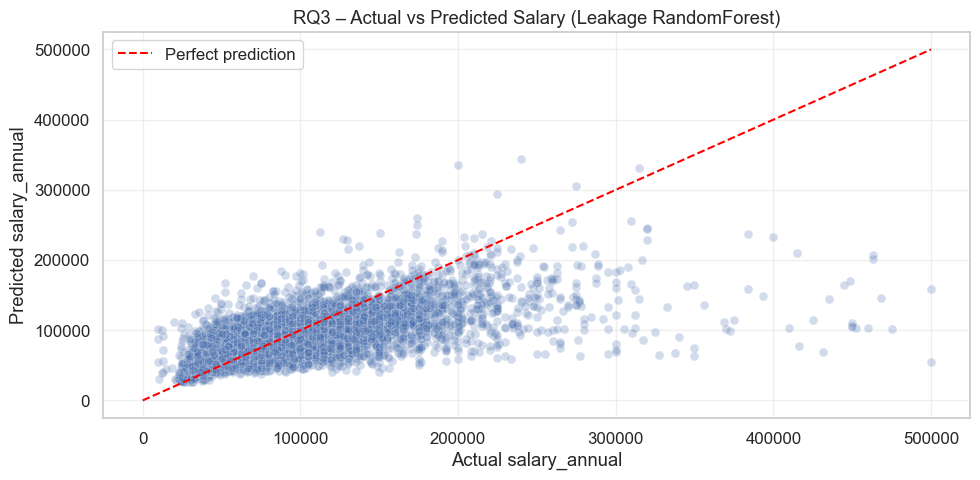

In [47]:
# Tạo DataFrame cho seaborn
plot_df = pd.DataFrame({"Actual salary": y_true, "Predicted salary": y_pred})

plt.figure(figsize=(10, 5))

sns.scatterplot(data=plot_df, x="Actual salary", y="Predicted salary", alpha=0.25, s=40)

# Đường dự đoán hoàn hảo
mx = max(plot_df.max())
plt.plot([0, mx], [0, mx], "--", color="red", label="Perfect prediction")

plt.title("RQ3 – Actual vs Predicted Salary (Leakage RandomForest)")
plt.xlabel("Actual salary_annual")
plt.ylabel("Predicted salary_annual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
X_test = X_test[numeric_features + categorical_features].copy()

perm = permutation_importance(
    model,
    X_test,
    y_test,  # y ở log space cho đúng pipeline
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error",
)

perm_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "perm_mean": perm.importances_mean,
        "perm_std": perm.importances_std,
    }
).sort_values("perm_mean", ascending=False)

display(perm_df)


,feature,perm_mean,perm_std
12,formatted_experience_level,1.343616e-01,2.605847e-03
3,follower_count,6.647428e-02,1.189118e-03
2,employee_count,4.020546e-02,1.080498e-03
5,num_skills,2.294991e-02,1.385867e-03
4,desc_len,2.186610e-02,8.336879e-04
13,formatted_work_type,1.424205e-02,1.221387e-03
15,application_type,1.363074e-02,7.268632e-04
10,state,1.198522e-02,5.890589e-04
11,city,8.951791e-03,4.507484e-04
0,views,6.792260e-03,6.188928e-04


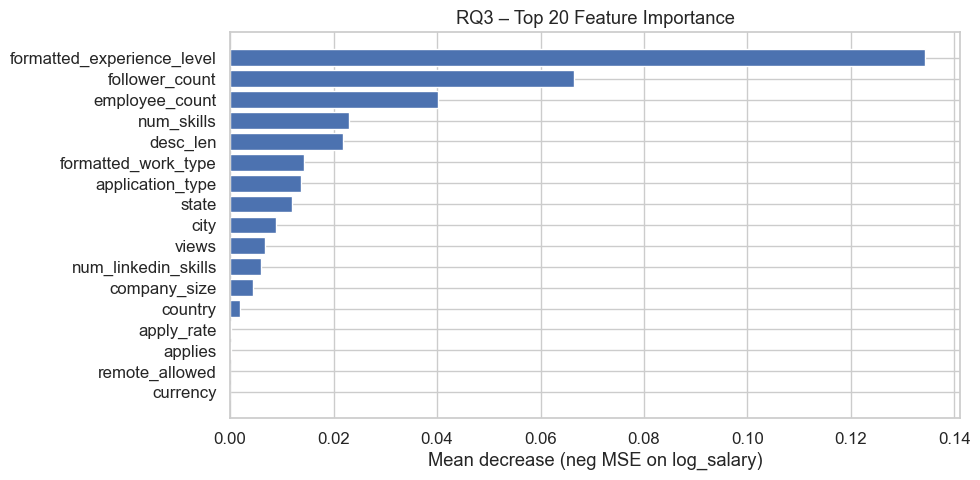

In [49]:

topN = 20
plt.barh(perm_df.head(topN)["feature"][::-1], perm_df.head(topN)["perm_mean"][::-1])
plt.title("RQ3 – Top 20 Feature Importance")
plt.xlabel("Mean decrease (neg MSE on log_salary)")
plt.tight_layout()
plt.show()